In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial


#define a_n, b_n multipole components (uniform in s)
a_n = [5,5,1, 20]
b_n = [0,4,3,1]
#define x axis
x = np.linspace(-1, 1, 101)

The field on axis can then be computed using 

$B_x(x, y=0, s) = \sum_{n=1}^\infty a_n(s) \frac{x^{n-1}}{(n-1)!} $

and 


$B_y(x, y=0, s) = \sum_{n=1}^\infty b_n(s) \frac{x^{n-1}}{(n-1)!}$

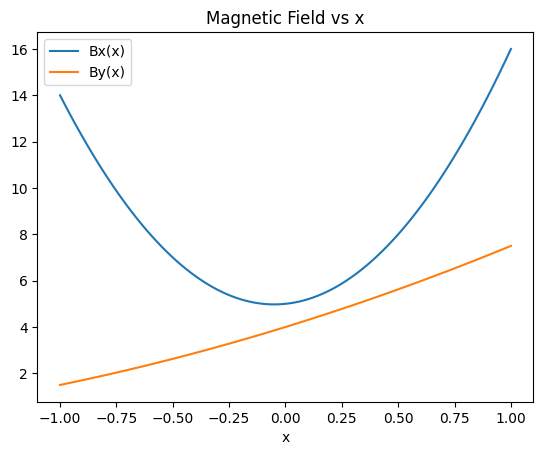

: 

: 

In [ ]:
def BxofxfromMultipole(x, a_n, b_n): 
    Bx = np.zeros(len(x))
    for i in range(len(x)):
        for n in range(1, len(a_n)):
            Bx[i] += a_n[n]*x[i]**(n-1) / factorial(n-1)
    return Bx
def ByofxfromMultipole(x, a_n, b_n):
    By = np.zeros(len(x))
    for i in range(len(x)):
        for n in range(1, len(b_n)):
            By[i] += b_n[n]*x[i]**(n-1) / factorial(n-1)
    return By
Bx=BxofxfromMultipole(x, a_n, b_n) 
By=ByofxfromMultipole(x, a_n, b_n)
plt.plot(x, Bx)
plt.plot(x, By)
plt.xlabel('x')
plt.legend(['Bx(x)', 'By(x)'])
plt.title('Magnetic Field vs x')           
plt.show()

Now we can go back to the multipole components using 

$a_{n}(s) = \left. \partial^{n-1}_x B_x(x,y,s) \right|_{x=y=0}$

and

$ b_{n}(s) = \left. \partial^{n-1}_x B_y(x,y,s) \right|_{x=y=0} $

In [ ]:
def derivativesFromField(x, B, max_order):
    dBvector=np.zeros((max_order+1, len(B)))
    dBvector[0,:]=B
    for i in range(1,max_order+1):
        dBvector[i,:]=np.gradient(dBvector[i-1,:], x)
    return dBvector
max_order = 3
idx_zero = np.argmin(np.abs(x))

dBxvector=derivativesFromField(x, Bx, max_order)
dByvector=derivativesFromField(x, By, max_order)
print("dBxvectorat x=0:", dBxvector[:, idx_zero])
print("dByvectorat x=0:", dByvector[:, idx_zero])

a_nnew=np.zeros(len(a_n))
b_nnew=np.zeros(len(b_n))
a_nnew[1:]=dBxvector[:max_order,idx_zero]
b_nnew[1:]=dByvector[:max_order,idx_zero]
print("Original a_n:", a_n)
print("Recovered a_n:", a_nnew)
print("Original b_n:", b_n)
print("Recovered b_n:", b_nnew)



dBxvectorat x=0: [5.0000000e+00 1.0000000e+00 2.0000000e+01 4.4508397e-11]
dByvectorat x=0: [ 4.00000000e+00  3.00000000e+00  1.00000000e+00 -5.29354338e-11]
Original a_n: [5, 5, 1, 20]
Recovered a_n: [ 0.  5.  1. 20.]
Original b_n: [0, 4, 3, 1]
Recovered b_n: [0. 4. 3. 1.]
